In [ ]:
from google.colab import drive
import os
import shutil

# Define the mount point
mount_point = '/content/drive'

# Check if the mount point exists and is not empty
if os.path.exists(mount_point) and os.listdir(mount_point):
    print(f"Mount point {mount_point} is not empty. Clearing directory...")
    # Remove all contents in the mount point
    for item in os.listdir(mount_point):
        item_path = os.path.join(mount_point, item)
        try:
            if os.path.isfile(item_path) or os.path.islink(item_path):
                os.unlink(item_path)
            elif os.path.isdir(item_path):
                shutil.rmtree(item_path)
        except Exception as e:
            print(f"Error removing {item_path}: {e}")

# Attempt to mount Google Drive
print(f"Attempting to mount Google Drive at {mount_point}...")
drive.mount(mount_point)

Attempting to mount Google Drive at /content/drive...
Mounted at /content/drive


In [ ]:
# train_gpt2_cnn_fixed_v2_OPTIMIZED.py
"""
CNN + GPT-2 - Memory optimized version
"""

import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import pandas as pd
from tqdm import tqdm
import gc  # للتنظيف

from transformers import GPT2Tokenizer, GPT2LMHeadModel, get_linear_schedule_with_warmup
from torch.optim import AdamW

# -------------------------
# Config - OPTIMIZED
# -------------------------
class Config:
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    BATCH_SIZE = 2  # ⬇️ خفضناه من 4 إلى 2
    GRADIENT_ACCUMULATION_STEPS = 2  # ✅ جديد - للحفاظ على effective batch size = 4
    EPOCHS = 8
    LR = 5e-5
    MAX_LENGTH = 128  # ⬇️ خفضناه من 150
    GPT2_MODEL = "gpt2"  # يمكن استخدام "distilgpt2" للذاكرة الأقل
    CSV_PATH = "/content/drive/Shareddrives/DEPI_GP/datasets/final_reports_filled.csv"
    CHECKPOINT_DIR = "/content/drive/MyDrive/checkpoints_gpt2_cnn_trainable"
    FREEZE_CNN = False  # ✅ تجميد CNN في البداية يوفر ذاكرة
    MIXED_PRECISION = True  # ✅ استخدام FP16
    MEMORY_CLEANUP_FREQ = 50  # تنظيف كل 50 batch

config = Config()
os.makedirs(config.CHECKPOINT_DIR, exist_ok=True)

# -------------------------
# Image transforms - OPTIMIZED
# -------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# -------------------------
# Dataset - OPTIMIZED
# -------------------------
class ReportsDataset(Dataset):
    def __init__(self, df, tokenizer, max_length, transform):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        f_path, l_path = row["frontal_path"], row["lateral_path"]

        # ✅ معالجة الصور بكفاءة
        with Image.open(f_path) as f_img:
            f_feat = self.transform(f_img.convert("RGB"))

        with Image.open(l_path) as l_img:
            l_feat = self.transform(l_img.convert("RGB"))

        # ✅ استخدم concatenation بدلاً من mean (أفضل للتمييز)
        img_tensor = torch.cat([f_feat, l_feat], dim=0)  # (6, 224, 224)

        text = str(row["structured_report"])
        tokens = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_length,
            padding="max_length",
            return_tensors="pt"
        )
        input_ids = tokens["input_ids"].squeeze(0)
        attention_mask = tokens["attention_mask"].squeeze(0)

        return img_tensor, input_ids, attention_mask

# -------------------------
# CNN + GPT-2 Model - OPTIMIZED
# -------------------------
class CNN_GPT2(nn.Module):
    def __init__(self, gpt2_model="gpt2"):
        super().__init__()
        # ✅ استخدم ResNet أصغر أو efficient
        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.cnn = nn.Sequential(*list(backbone.children())[:-2])  # Keep spatial features
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.gpt2 = GPT2LMHeadModel.from_pretrained(gpt2_model)

        # ✅ تعامل مع الصور المدمجة
        self.linear = nn.Linear(backbone.fc.in_features * 2, self.gpt2.config.n_embd)
        self.dropout = nn.Dropout(0.1)

    def forward(self, img_tensor, input_ids, attention_mask):
        # img_tensor: (B, 6, 224, 224) - 2 images concatenated
        B = img_tensor.size(0)

        # Split and process each image
        img1 = img_tensor[:, :3, :, :]  # frontal
        img2 = img_tensor[:, 3:, :, :]  # lateral

        feat1 = self.pool(self.cnn(img1)).squeeze(-1).squeeze(-1)
        feat2 = self.pool(self.cnn(img2)).squeeze(-1).squeeze(-1)

        # ✅ دمج الـ features
        cnn_feat = torch.cat([feat1, feat2], dim=1)
        prefix_emb = self.dropout(self.linear(cnn_feat)).unsqueeze(1)

        gpt_emb = self.gpt2.transformer.wte(input_ids)
        gpt_emb = torch.cat([prefix_emb, gpt_emb], dim=1)

        prefix_mask = torch.ones((attention_mask.size(0), 1), device=attention_mask.device)
        attn_mask = torch.cat([prefix_mask, attention_mask], dim=1)

        prefix_token_id = self.gpt2.config.pad_token_id
        if prefix_token_id is None:
            prefix_token_id = self.gpt2.config.eos_token_id

        labels = torch.cat([
            torch.full((input_ids.size(0), 1), prefix_token_id,
                      dtype=torch.long, device=input_ids.device),
            input_ids
        ], dim=1)

        outputs = self.gpt2(inputs_embeds=gpt_emb, attention_mask=attn_mask, labels=labels)
        return outputs

# -------------------------
# Training function - OPTIMIZED
# -------------------------
def train_model(df):
    tokenizer = GPT2Tokenizer.from_pretrained(config.GPT2_MODEL)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    train_df = df.sample(frac=0.8, random_state=42)
    val_df = df.drop(train_df.index)

    train_ds = ReportsDataset(train_df, tokenizer, config.MAX_LENGTH, transform)
    val_ds = ReportsDataset(val_df, tokenizer, config.MAX_LENGTH, transform)

    # ✅ استخدم num_workers=0 لتوفير الذاكرة
    train_loader = DataLoader(train_ds, batch_size=config.BATCH_SIZE,
                             shuffle=True, num_workers=0, pin_memory=False)
    val_loader = DataLoader(val_ds, batch_size=config.BATCH_SIZE,
                           num_workers=0, pin_memory=False)

    model = CNN_GPT2(config.GPT2_MODEL).to(config.DEVICE)

    if config.FREEZE_CNN:
        print("🔒 Freezing CNN backbone...")
        for p in model.cnn.parameters():
            p.requires_grad = False

    optimizer = AdamW(model.parameters(), lr=config.LR, weight_decay=0.01)
    total_steps = len(train_loader) * config.EPOCHS // config.GRADIENT_ACCUMULATION_STEPS
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=100,
        num_training_steps=total_steps
    )

    # ✅ Mixed Precision Training
    scaler = torch.cuda.amp.GradScaler() if config.MIXED_PRECISION else None

    for epoch in range(1, config.EPOCHS + 1):
        model.train()
        total_loss = 0
        optimizer.zero_grad()

        pbar = tqdm(train_loader, desc=f"Epoch {epoch}")
        for batch_idx, (img_tensor, input_ids, attention_mask) in enumerate(pbar):
            img_tensor = img_tensor.to(config.DEVICE)
            input_ids = input_ids.to(config.DEVICE)
            attention_mask = attention_mask.to(config.DEVICE)

            # ✅ Mixed precision forward pass
            if config.MIXED_PRECISION:
                with torch.cuda.amp.autocast():
                    outputs = model(img_tensor, input_ids, attention_mask)
                    loss = outputs.loss / config.GRADIENT_ACCUMULATION_STEPS

                scaler.scale(loss).backward()
            else:
                outputs = model(img_tensor, input_ids, attention_mask)
                loss = outputs.loss / config.GRADIENT_ACCUMULATION_STEPS
                loss.backward()

            # ✅ Gradient accumulation
            if (batch_idx + 1) % config.GRADIENT_ACCUMULATION_STEPS == 0:
                if config.MIXED_PRECISION:
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    optimizer.step()

                scheduler.step()
                optimizer.zero_grad()

            total_loss += loss.item() * config.GRADIENT_ACCUMULATION_STEPS
            pbar.set_postfix(loss=total_loss / (batch_idx + 1))

            # ✅ تنظيف دوري للذاكرة
            if (batch_idx + 1) % config.MEMORY_CLEANUP_FREQ == 0:
                torch.cuda.empty_cache()
                gc.collect()

        # ✅ حفظ checkpoint بعد كل epoch
        checkpoint_path = os.path.join(config.CHECKPOINT_DIR, f"model_epoch_{epoch}.pt")
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': total_loss / len(train_loader),
        }, checkpoint_path)
        print(f"💾 Checkpoint saved: {checkpoint_path}")

        # ✅ تنظيف بعد كل epoch
        torch.cuda.empty_cache()
        gc.collect()
    final_model_path = "final_cnn_gpt2_model.pth"
    torch.save(model.state_dict(), final_model_path)
    print(f"🎉 Final model saved for inference: {final_model_path}")

    return model, tokenizer

# -------------------------
# Report Generator - OPTIMIZED
# -------------------------
class ReportGenerator:
    def __init__(self, model, tokenizer, device="cuda", max_length=128):
        self.model = model
        self.tokenizer = tokenizer
        self.device = device
        self.max_length = max_length

    @torch.no_grad()
    def generate(self, img_tensor):
        self.model.eval()

        if isinstance(img_tensor, Image.Image):
            img_tensor = transform(img_tensor)

        # ✅ للصورة الواحدة، كرر لتتطابق مع الشكل المتوقع
        if img_tensor.size(0) == 3:
            img_tensor = torch.cat([img_tensor, img_tensor], dim=0)

        img_tensor = img_tensor.unsqueeze(0).to(self.device)

        input_ids = torch.tensor([[self.tokenizer.pad_token_id]], device=self.device)
        attention_mask = torch.ones_like(input_ids, device=self.device)

        generated = input_ids

        for _ in range(self.max_length):
            outputs = self.model(img_tensor, generated, attention_mask)
            next_token = torch.argmax(outputs.logits[0, -1, :]).unsqueeze(0)

            if next_token.item() == self.tokenizer.eos_token_id:
                break

            generated = torch.cat([generated, next_token.unsqueeze(0)], dim=1)
            attention_mask = torch.ones_like(generated, device=self.device)

        text = self.tokenizer.decode(generated[0].tolist(), skip_special_tokens=True)
        return text

# -------------------------
# Main
# -------------------------
if __name__ == "__main__":
    # ✅ تنظيف أولي
    torch.cuda.empty_cache()
    gc.collect()

    df = pd.read_csv(config.CSV_PATH)

    def process_report(text):
        text = str(text).lower()
        findings, impression = "", ""
        if "impression:" in text:
            parts = text.split("impression:")
            findings = parts[0].replace("findings:", "").strip()
            impression = parts[1].strip()
        else:
            findings = text.replace("findings:", "").strip()
        return f"<start1> {findings} <end1> <start2> {impression} <end2>"

    df["structured_report"] = df["clean_report"].apply(process_report)

    print(f"🚀 Starting training with optimized settings:")
    print(f"   - Batch size: {config.BATCH_SIZE}")
    print(f"   - Gradient accumulation: {config.GRADIENT_ACCUMULATION_STEPS}")
    print(f"   - Effective batch size: {config.BATCH_SIZE * config.GRADIENT_ACCUMULATION_STEPS}")
    print(f"   - Mixed precision: {config.MIXED_PRECISION}")
    print(f"   - CNN frozen: {config.FREEZE_CNN}")

    model, tokenizer = train_model(df)
    print("✅ Training finished successfully!")

    # Test generation
    reporter = ReportGenerator(model, tokenizer, device=config.DEVICE)
    sample_path = df.iloc[0]["frontal_path"]
    img = Image.open(sample_path).convert("RGB")
    text = reporter.generate(img)
    print("\n📄 Generated report:", text)


ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipython-input-4292767929.py", line 16, in <cell line: 0>
    from transformers import GPT2Tokenizer, GPT2LMHeadModel, get_linear_schedule_with_warmup
  File "/usr/local/lib/python3.12/dist-packages/transformers/__init__.py", line 27, in <module>
    from . import dependency_versions_check
  File "/usr/local/lib/python3.12/dist-packages/transformers/dependency_versions_check.py", line 16, in <module>
    from .utils.versions import require_version, require_version_core
  File "/usr/local/lib/python3.12/dist-packages/transformers/utils/__init__.py", line 19, in <module>
    from huggingface_hub import get_full_repo_name  # for backward compatibility
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1412, in _handle_fromlist
  File "/usr/l

TypeError: object of type 'NoneType' has no len()

In [ ]:
!pip install nltk rouge-score matplotlib seaborn


  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=7ff583f14cc836afb7ee1aec7b9c543e904954be25c3f8823338c08e28a74475
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score


🚀 Starting Inference Process

📂 Loading dataset...
  Test samples: 587

🔤 Loading tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(



🧠 Loading model...
  ✅ Loaded checkpoint from epoch 8
  Training loss: 0.4262

📦 Configuring DataLoader with multiprocessing for faster image loading...

🔍 Running inference on test set...


Generating reports:   0%|          | 0/587 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:389: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:394: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
Generating reports: 100%|██████████| 587/587 [12:05<00:00,  1.24s/it]



📊 Creating summary visualizations...

✅ INFERENCE COMPLETED!

📁 Results saved to: /content/drive/MyDrive/GOT2WithcnnTi_nference_results
  - Summary report: /content/drive/MyDrive/GOT2WithcnnTi_nference_results/summary_report.txt
  - Full results CSV: /content/drive/MyDrive/GOT2WithcnnTi_nference_results/inference_results.csv
  - Sample visualizations: 10 samples

📈 AVERAGE METRICS:
--------------------------------------------------------------------------------
  BLEU1: 0.3656 ± 0.1384
  BLEU2: 0.2296 ± 0.1233
  BLEU4: 0.0973 ± 0.1033
  ROUGE1_F: 0.5040 ± 0.1198
  ROUGE2_F: 0.2130 ± 0.1239
  ROUGEL_F: 0.3906 ± 0.1248

🎉 Done!

💡 TIP: You can view specific samples using:
  view_specific_sample(idx, all_results)

📌 Viewing first 3 samples as examples (images may not display in terminal):

SAMPLE 0


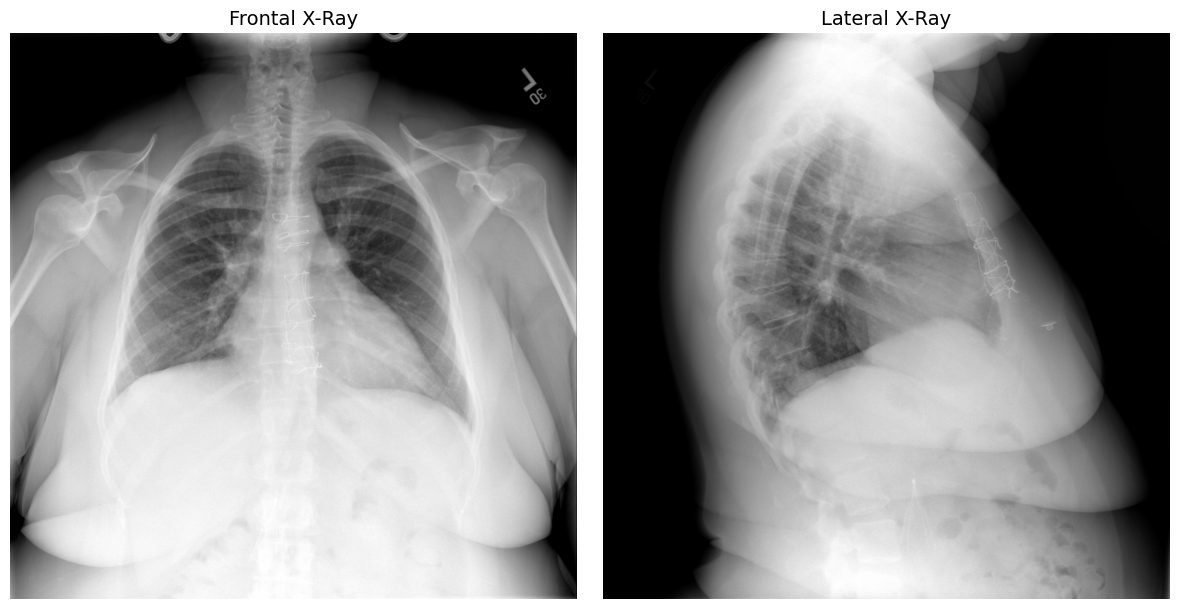


📄 GROUND TRUTH:
--------------------------------------------------------------------------------
<start1> borderline cardiomegaly. midline sternotomy unknown. enlarged pulmonary arteries. clear lungs. inferior unknown unknown unknown. <end1> <start2> no acute pulmonary findings:. <end2>

📝 GENERATED REPORT:
--------------------------------------------------------------------------------
<start1> the cardiomediastinal silhouette and pulmonary vasculature are within normal limits in size. the lungs are clear of focal airspace disease pneumothorax or pleural effusion. there are no acute bony. <end1> <start2> no acute cardiopulmonary findings:.. <end2>

📊 METRICS:
--------------------------------------------------------------------------------
  bleu1: 0.2162
  bleu2: 0.1342
  bleu4: 0.0742
  rouge1_f: 0.3390
  rouge2_f: 0.1404
  rougeL_f: 0.3051

SAMPLE 1


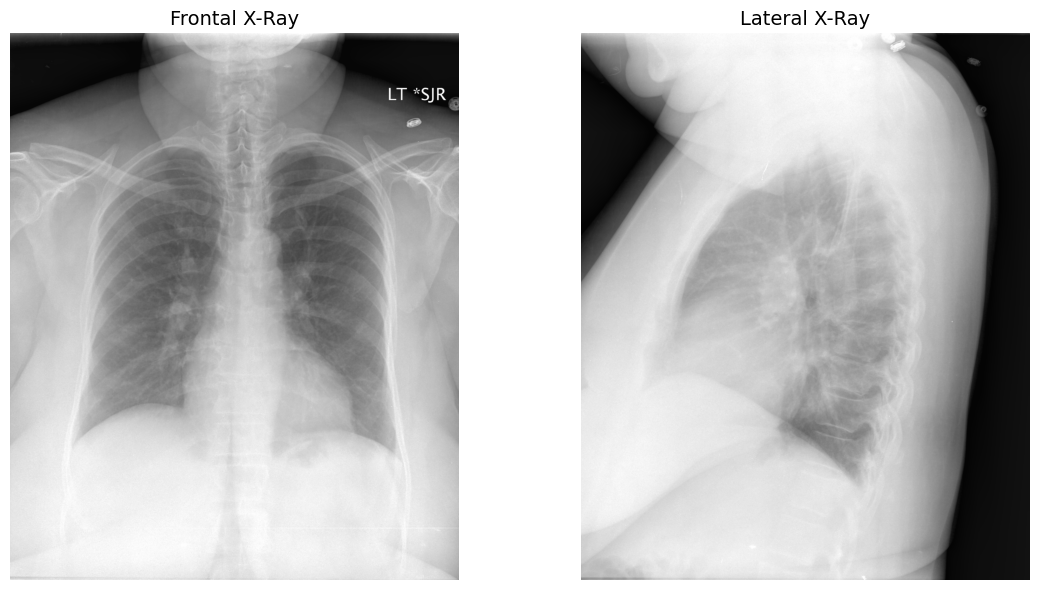


📄 GROUND TRUTH:
--------------------------------------------------------------------------------
<start1> heart size and mediastinal contour are within normal limits. there is no focal airspace consolidation or suspicious pulmonary opacity. no pneumothorax or large pleural effusion. mild degenerative change of the thoracic spine. <end1> <start2> no acute cardiopulmonary findings:. <end2>

📝 GENERATED REPORT:
--------------------------------------------------------------------------------
<start1> the cardiomediastinal silhouette and pulmonary vasculature are within normal limits in size. the lungs are clear of focal airspace disease pneumothorax or pleural effusion. there are no acute bony. <end1> <start2> no acute cardiopulmonary findings:.. <end2>

📊 METRICS:
--------------------------------------------------------------------------------
  bleu1: 0.5483
  bleu2: 0.3555
  bleu4: 0.1640
  rouge1_f: 0.6494
  rouge2_f: 0.3200
  rougeL_f: 0.4935

SAMPLE 2


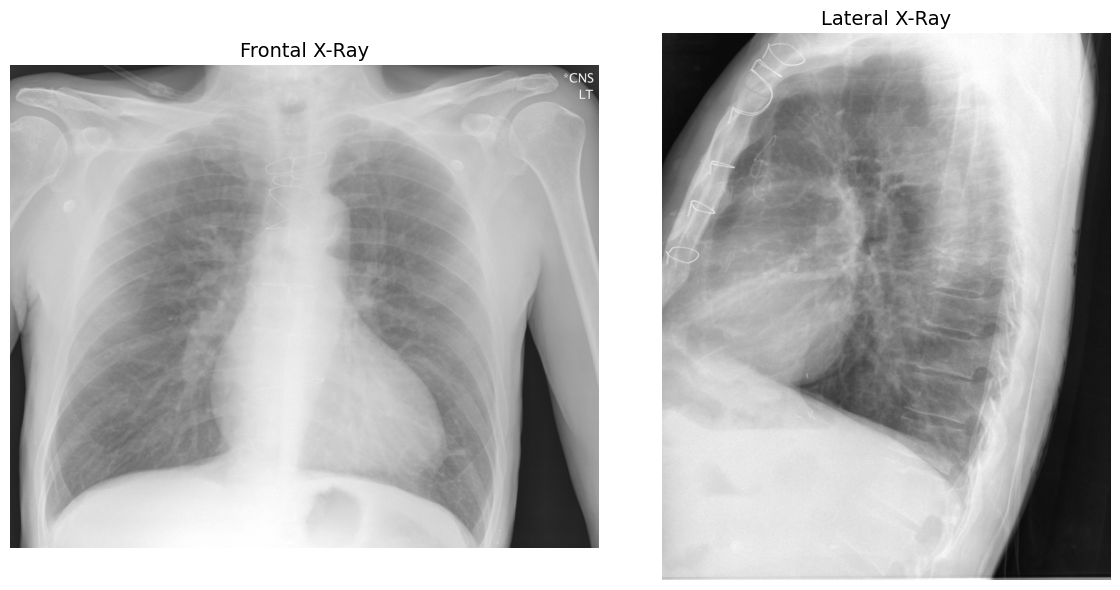


📄 GROUND TRUTH:
--------------------------------------------------------------------------------
<start1> the cardiac silhouette is borderline enlarged. otherwise there is no focal opacity. mediastinal contours are within normal limits. there is no large pleural effusion. no pneumothorax. <end1> <start2> borderline enlargement of the cardiac silhouette without acute pulmonary disease. <end2>

📝 GENERATED REPORT:
--------------------------------------------------------------------------------
<start1> the cardiomediastinal silhouette and pulmonary vasculature are within normal limits in size. the lungs are clear of focal airspace disease pneumothorax or pleural effusion. there are no acute bony. <end1> <start2> no acute cardiopulmonary findings:.. <end2>

📊 METRICS:
--------------------------------------------------------------------------------
  bleu1: 0.4735
  bleu2: 0.2463
  bleu4: 0.0456
  rouge1_f: 0.5714
  rouge2_f: 0.1600
  rougeL_f: 0.3636


In [ ]:
# inference_gpt2_cnn.py
"""
Inference Script for CNN + GPT-2 Model
يقوم بتحميل الموديل المدرب وتقييمه على test set
"""

import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
# import seaborn as sns # تم حذفها لعدم استخدامها بشكل مباشر
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
import numpy as np
from collections import defaultdict
import multiprocessing # لاستخدام عدد الأنوية المتاحة

from transformers import GPT2Tokenizer, GPT2LMHeadModel

# -------------------------
# Config
# -------------------------
class InferenceConfig:
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    BATCH_SIZE = 1
    MAX_LENGTH = 128
    GPT2_MODEL = "gpt2"

    # Paths
    CSV_PATH = "/content/drive/Shareddrives/DEPI_GP/datasets/final_reports_filled.csv"
    CHECKPOINT_PATH = "/content/drive/Shareddrives/DEPI_GP/models/Reports_models/reportsmodel_withcnnT_gpt2_bestmodel-.pt"
    OUTPUT_DIR = "/content/drive/MyDrive/GOT2WithcnnTi_nference_results"

    # Generation settings
    TEMPERATURE = 0.7
    TOP_K = 50
    TOP_P = 0.9
    NUM_BEAMS = 4
    REPETITION_PENALTY = 1.2
    NUM_SAMPLES = 10

config = InferenceConfig()
os.makedirs(config.OUTPUT_DIR, exist_ok=True)

# -------------------------
# Image transforms (نفس التدريب)
# -------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# -------------------------
# Dataset للـ Inference
# -------------------------
class InferenceDataset(Dataset):
    def __init__(self, df, tokenizer, max_length, transform):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        f_path, l_path = row["frontal_path"], row["lateral_path"]

        # هذه الأسطر هي التي يتم تنفيذها في كل مرة.
        # تشغيلها في workers متوازية يسرع العملية.
        with Image.open(f_path) as f_img:
            f_feat = self.transform(f_img.convert("RGB"))

        with Image.open(l_path) as l_img:
            l_feat = self.transform(l_img.convert("RGB"))

        # دمج الصورتين (6 قنوات)
        img_tensor = torch.cat([f_feat, l_feat], dim=0)

        text = str(row["structured_report"])

        return {
            'img_tensor': img_tensor,
            'ground_truth': text,
            'frontal_path': f_path,
            'lateral_path': l_path,
            'original_report': str(row.get("clean_report", "")),
            'idx': idx
        }

# -------------------------
# Model Definition (نفس التدريب)
# -------------------------
class CNN_GPT2(nn.Module):
    def __init__(self, gpt2_model="gpt2"):
        super().__init__()
        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.cnn = nn.Sequential(*list(backbone.children())[:-2])
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.gpt2 = GPT2LMHeadModel.from_pretrained(gpt2_model)
        self.linear = nn.Linear(backbone.fc.in_features * 2, self.gpt2.config.n_embd)
        self.dropout = nn.Dropout(0.1)

    def forward(self, img_tensor, input_ids, attention_mask):
        B = img_tensor.size(0)

        img1 = img_tensor[:, :3, :, :]
        img2 = img_tensor[:, 3:, :, :]

        feat1 = self.pool(self.cnn(img1)).squeeze(-1).squeeze(-1)
        feat2 = self.pool(self.cnn(img2)).squeeze(-1).squeeze(-1)

        cnn_feat = torch.cat([feat1, feat2], dim=1)
        prefix_emb = self.dropout(self.linear(cnn_feat)).unsqueeze(1)

        gpt_emb = self.gpt2.transformer.wte(input_ids)
        gpt_emb = torch.cat([prefix_emb, gpt_emb], dim=1)

        prefix_mask = torch.ones((attention_mask.size(0), 1), device=attention_mask.device)
        attn_mask = torch.cat([prefix_mask, attention_mask], dim=1)

        prefix_token_id = self.gpt2.config.pad_token_id
        if prefix_token_id is None:
            prefix_token_id = self.gpt2.config.eos_token_id

        labels = torch.cat([
            torch.full((input_ids.size(0), 1), prefix_token_id,
                       dtype=torch.long, device=input_ids.device),
            input_ids
        ], dim=1)

        outputs = self.gpt2(inputs_embeds=gpt_emb, attention_mask=attn_mask, labels=labels)
        return outputs

# -------------------------
# Report Generator with Advanced Options - الكلاس المعدل
# -------------------------
class AdvancedReportGenerator:
    def __init__(self, model, tokenizer, device="cuda", max_length=128):
        self.model = model
        self.tokenizer = tokenizer
        self.device = device
        self.max_length = max_length
        self.model.eval()

    @torch.no_grad()
    def generate(self, img_tensor, temperature=0.7, top_k=50, top_p=0.9,
                 num_beams=4, repetition_penalty=1.2):
        """
        Generate report using the model's 'generate' function with prefix embeddings.
        """
        # 1. تجهيز موتر الصورة
        if img_tensor.ndim == 3:
            img_tensor = img_tensor.unsqueeze(0).to(self.device)
        elif img_tensor.ndim == 4 and img_tensor.size(0) == 1:
            img_tensor = img_tensor.to(self.device)
        else:
            img_tensor = img_tensor.unsqueeze(0).to(self.device)

        # 2. استخراج التضمينات البصرية (Prefix Embeddings)
        img1 = img_tensor[:, :3, :, :]
        img2 = img_tensor[:, 3:, :, :]

        feat1 = self.model.pool(self.model.cnn(img1)).squeeze(-1).squeeze(-1)
        feat2 = self.model.pool(self.model.cnn(img2)).squeeze(-1).squeeze(-1)

        cnn_feat = torch.cat([feat1, feat2], dim=1)
        prefix_emb = self.model.dropout(self.model.linear(cnn_feat)).unsqueeze(1)

        # 3. دمج التضمين البصري مع رمز البداية (BOS)
        start_token_id = self.tokenizer.bos_token_id if self.tokenizer.bos_token_id is not None else self.tokenizer.pad_token_id
        dummy_input_ids = torch.tensor([[start_token_id]], device=self.device)
        start_gpt_emb = self.model.gpt2.transformer.wte(dummy_input_ids)
        # ندمج التضمين البصري (prefix_emb) مع تضمين رمز البداية (start_gpt_emb).
        # combined_emb.shape هو: (1, 2, n_embd)
        combined_emb = torch.cat([prefix_emb, start_gpt_emb], dim=1)

        # 4. **إنشاء قناع الانتباه (Attention Mask):**
        # الطول يجب أن يساوي طول combined_emb (وهو 2: 1 للـ prefix + 1 لرمز البداية).
        # القيمة 1 تشير إلى أن هذا الـ token/embedding يجب أن ينتبه إليه النموذج.
        attention_mask = torch.ones(
            combined_emb.shape[:2], # الحجم (1, 2)
            device=self.device,
            dtype=torch.long
        )

        # 5. استخدام دالة 'generate' المُحسّنة مع تمرير القناع
        output_sequences = self.model.gpt2.generate(
            inputs_embeds=combined_emb,
            attention_mask=attention_mask, # <-- يجب تمرير قناع الانتباه هنا
            max_length=self.max_length,
            do_sample=(num_beams == 1),
            num_beams=num_beams,
            temperature=temperature,
            top_k=top_k,
            top_p=top_p,
            repetition_penalty=repetition_penalty,
            pad_token_id=self.tokenizer.pad_token_id,
            eos_token_id=self.tokenizer.eos_token_id,
            num_return_sequences=1
        )

        generated_tokens = output_sequences[0, 1:].tolist()
        text = self.tokenizer.decode(generated_tokens, skip_special_tokens=True)
        return text

# -------------------------
# Evaluation Metrics
# -------------------------
class MetricsCalculator:
    # (باقي كود MetricsCalculator كما هو)
    def __init__(self):
        self.rouge_scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'],
                                                     use_stemmer=True)
        self.smoothing = SmoothingFunction().method1

    def calculate_bleu(self, reference, hypothesis):
        """Calculate BLEU score"""
        ref_tokens = reference.lower().split()
        hyp_tokens = hypothesis.lower().split()

        try:
            bleu1 = sentence_bleu([ref_tokens], hyp_tokens, weights=(1, 0, 0, 0),
                                  smoothing_function=self.smoothing)
            bleu2 = sentence_bleu([ref_tokens], hyp_tokens, weights=(0.5, 0.5, 0, 0),
                                  smoothing_function=self.smoothing)
            bleu4 = sentence_bleu([ref_tokens], hyp_tokens, weights=(0.25, 0.25, 0.25, 0.25),
                                  smoothing_function=self.smoothing)
            return {'bleu1': bleu1, 'bleu2': bleu2, 'bleu4': bleu4}
        except:
            return {'bleu1': 0.0, 'bleu2': 0.0, 'bleu4': 0.0}

    def calculate_rouge(self, reference, hypothesis):
        """Calculate ROUGE scores"""
        try:
            scores = self.rouge_scorer.score(reference, hypothesis)
            return {
                'rouge1_f': scores['rouge1'].fmeasure,
                'rouge2_f': scores['rouge2'].fmeasure,
                'rougeL_f': scores['rougeL'].fmeasure,
            }
        except:
            return {'rouge1_f': 0.0, 'rouge2_f': 0.0, 'rougeL_f': 0.0}

    def calculate_all_metrics(self, reference, hypothesis):
        """Calculate all metrics"""
        metrics = {}
        metrics.update(self.calculate_bleu(reference, hypothesis))
        metrics.update(self.calculate_rouge(reference, hypothesis))
        return metrics

# -------------------------
# Visualization Functions
# -------------------------
# (باقي كود Visualization Functions كما هو)
def visualize_sample(sample_data, output_dir):
    """Visualize a single sample with images and reports"""
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    frontal_img = Image.open(sample_data['frontal_path']).convert('RGB')
    lateral_img = Image.open(sample_data['lateral_path']).convert('RGB')

    axes[0].imshow(frontal_img)
    axes[0].set_title('Frontal X-Ray')
    axes[0].axis('off')

    axes[1].imshow(lateral_img)
    axes[1].set_title('Lateral X-Ray')
    axes[1].axis('off')

    plt.tight_layout()
    img_path = os.path.join(output_dir, f"sample_{sample_data['idx']}_images.png")
    plt.savefig(img_path, dpi=150, bbox_inches='tight')
    plt.close()

    text_path = os.path.join(output_dir, f"sample_{sample_data['idx']}_report.txt")
    with open(text_path, 'w', encoding='utf-8') as f:
        f.write("="*80 + "\n")
        f.write(f"SAMPLE {sample_data['idx']}\n")
        f.write("="*80 + "\n\n")

        f.write("GROUND TRUTH:\n")
        f.write("-"*80 + "\n")
        f.write(sample_data['ground_truth'] + "\n\n")

        f.write("GENERATED REPORT:\n")
        f.write("-"*80 + "\n")
        f.write(sample_data['generated'] + "\n\n")

        f.write("METRICS:\n")
        f.write("-"*80 + "\n")
        for metric, value in sample_data['metrics'].items():
            f.write(f"{metric}: {value:.4f}\n")

    return img_path, text_path

def plot_metrics_distribution(all_metrics, output_dir):
    """Plot distribution of metrics across all samples"""
    metrics_dict = defaultdict(list)
    for metrics in all_metrics:
        for key, value in metrics.items():
            metrics_dict[key].append(value)

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    metric_names = list(metrics_dict.keys())
    for idx, metric_name in enumerate(metric_names):
        if idx >= len(axes):
            break

        data = metrics_dict[metric_name]
        axes[idx].hist(data, bins=20, edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'{metric_name.upper()}\nMean: {np.mean(data):.4f}')
        axes[idx].set_xlabel('Score')
        axes[idx].set_ylabel('Frequency')
        axes[idx].grid(True, alpha=0.3)

    plt.tight_layout()
    dist_path = os.path.join(output_dir, 'metrics_distribution.png')
    plt.savefig(dist_path, dpi=150, bbox_inches='tight')
    plt.close()

    return dist_path

def create_summary_report(all_metrics, output_dir):
    """Create a comprehensive summary report"""
    metrics_dict = defaultdict(list)
    for metrics in all_metrics:
        for key, value in metrics.items():
            metrics_dict[key].append(value)

    summary_path = os.path.join(output_dir, 'summary_report.txt')
    with open(summary_path, 'w', encoding='utf-8') as f:
        f.write("="*80 + "\n")
        f.write("INFERENCE SUMMARY REPORT\n")
        f.write("="*80 + "\n\n")

        f.write(f"Total Samples: {len(all_metrics)}\n")
        f.write(f"Device: {config.DEVICE}\n")
        f.write(f"Model: {config.GPT2_MODEL}\n")
        f.write(f"Checkpoint: {config.CHECKPOINT_PATH}\n\n")

        f.write("GENERATION SETTINGS:\n")
        f.write(f"  Temperature: {config.TEMPERATURE}\n")
        f.write(f"  Top K:       {config.TOP_K}\n")
        f.write(f"  Top P:       {config.TOP_P}\n")
        f.write(f"  Num Beams:   {config.NUM_BEAMS}\n")
        f.write(f"  Repetition Penalty: {config.REPETITION_PENALTY}\n\n")

        f.write("METRICS STATISTICS:\n")
        f.write("-"*80 + "\n")

        for metric_name, values in metrics_dict.items():
            f.write(f"\n{metric_name.upper()}:\n")
            f.write(f"  Mean:   {np.mean(values):.4f}\n")
            f.write(f"  Median: {np.median(values):.4f}\n")
            f.write(f"  Std:    {np.std(values):.4f}\n")
            f.write(f"  Min:    {np.min(values):.4f}\n")
            f.write(f"  Max:    {np.max(values):.4f}\n")

    return summary_path

# -------------------------
# Main Inference Function - التعديل في num_workers
# -------------------------
def run_inference():
    print("="*80)
    print("🚀 Starting Inference Process")
    print("="*80)

    # Load data
    print("\n📂 Loading dataset...")
    df = pd.read_csv(config.CSV_PATH)

    # Process reports (same as training)
    def process_report(text):
        text = str(text).lower()
        findings, impression = "", ""
        if "impression:" in text:
            parts = text.split("impression:")
            findings = parts[0].replace("findings:", "").strip()
            impression = parts[1].strip()
        else:
            findings = text.replace("findings:", "").strip()
        return f"<start1> {findings} <end1> <start2> {impression} <end2>"

    df["structured_report"] = df["clean_report"].apply(process_report)

    # Split data (use test set = 20%)
    train_df = df.sample(frac=0.8, random_state=42)
    test_df = df.drop(train_df.index).reset_index(drop=True)

    print(f"  Test samples: {len(test_df)}")

    # Load tokenizer
    print("\n🔤 Loading tokenizer...")
    # tokenizer = GPT2Tokenizer.from_pretrained(config.GPT2_MODEL)
    tokenizer = GPT2Tokenizer.from_pretrained(
    config.GPT2_MODEL,
    trust_remote_code=False,
    revision="main"
)
    tokenizer.chat_template = None  # disable chat templates fully

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    # Load model
    print("\n🧠 Loading model...")
    model = CNN_GPT2(config.GPT2_MODEL).to(config.DEVICE)

    checkpoint = torch.load(config.CHECKPOINT_PATH, map_location=config.DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    print(f"  ✅ Loaded checkpoint from epoch {checkpoint.get('epoch', 'unknown')}")
    print(f"  Training loss: {checkpoint.get('loss', 'unknown'):.4f}")

    # Create dataset and dataloader
    print("\n📦 Configuring DataLoader with multiprocessing for faster image loading...")

    # استخدام عدد معقول من العمال (workers) لتحميل الصور بشكل متوازي
    # نقترح استخدام عدد أقل من إجمالي الأنوية لتجنب التحميل الزائد
    num_dataloader_workers = min(4, multiprocessing.cpu_count())

    test_dataset = InferenceDataset(test_df, tokenizer, config.MAX_LENGTH, transform)
    test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE,
                             shuffle=False, num_workers=num_dataloader_workers) # <--- التعديل هنا

    # Initialize generator and metrics calculator
    generator = AdvancedReportGenerator(model, tokenizer, config.DEVICE, config.MAX_LENGTH)
    metrics_calc = MetricsCalculator()

    # Run inference
    print("\n🔍 Running inference on test set...")
    all_results = []
    all_metrics = []

    for batch_idx, batch in enumerate(tqdm(test_loader, desc="Generating reports")):
        img_tensor = batch['img_tensor'][0]  # Remove batch dimension
        ground_truth = batch['ground_truth'][0]

        # Generate report
        generated_text = generator.generate(
            img_tensor,
            temperature=config.TEMPERATURE,
            top_k=config.TOP_K,
            top_p=config.TOP_P,
            num_beams=config.NUM_BEAMS,
            repetition_penalty=config.REPETITION_PENALTY
        )

        # Calculate metrics
        metrics = metrics_calc.calculate_all_metrics(ground_truth, generated_text)

        # Store results
        result = {
            'idx': batch['idx'][0].item(),
            'frontal_path': batch['frontal_path'][0],
            'lateral_path': batch['lateral_path'][0],
            'ground_truth': ground_truth,
            'generated': generated_text,
            'metrics': metrics
        }

        all_results.append(result)
        all_metrics.append(metrics)

        # Visualize first N samples
        if batch_idx < config.NUM_SAMPLES:
            visualize_sample(result, config.OUTPUT_DIR)

    # Create summary visualizations and reports
    print("\n📊 Creating summary visualizations...")
    plot_metrics_distribution(all_metrics, config.OUTPUT_DIR)
    summary_path = create_summary_report(all_metrics, config.OUTPUT_DIR)

    # Save all results to CSV
    results_df = pd.DataFrame([
        {
            'idx': r['idx'],
            'ground_truth': r['ground_truth'],
            'generated': r['generated'],
            **r['metrics']
        }
        for r in all_results
    ])

    csv_path = os.path.join(config.OUTPUT_DIR, 'inference_results.csv')
    results_df.to_csv(csv_path, index=False)

    # Print summary
    print("\n" + "="*80)
    print("✅ INFERENCE COMPLETED!")
    print("="*80)
    print(f"\n📁 Results saved to: {config.OUTPUT_DIR}")
    print(f"  - Summary report: {summary_path}")
    print(f"  - Full results CSV: {csv_path}")
    print(f"  - Sample visualizations: {config.NUM_SAMPLES} samples")

    # Print average metrics
    print("\n📈 AVERAGE METRICS:")
    print("-"*80)
    metrics_dict = defaultdict(list)
    for metrics in all_metrics:
        for key, value in metrics.items():
            metrics_dict[key].append(value)

    for metric_name, values in sorted(metrics_dict.items()):
        print(f"  {metric_name.upper()}: {np.mean(values):.4f} ± {np.std(values):.4f}")

    print("\n🎉 Done!")

    return all_results, all_metrics

# -------------------------
# Interactive Sample Viewer
# -------------------------
def view_specific_sample(sample_idx, all_results):
    # (باقي كود view_specific_sample كما هو)
    """View a specific sample interactively"""
    if sample_idx >= len(all_results):
        print(f"❌ Sample {sample_idx} not found. Max index: {len(all_results)-1}")
        return

    result = all_results[sample_idx]

    print("\n" + "="*80)
    print(f"SAMPLE {result['idx']}")
    print("="*80)

    # Display images
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    try:
        frontal_img = Image.open(result['frontal_path']).convert('RGB')
        lateral_img = Image.open(result['lateral_path']).convert('RGB')

        axes[0].imshow(frontal_img)
        axes[0].set_title('Frontal X-Ray', fontsize=14)
        axes[0].axis('off')

        axes[1].imshow(lateral_img)
        axes[1].set_title('Lateral X-Ray', fontsize=14)
        axes[1].axis('off')

        plt.tight_layout()
        plt.show()
    except:
        print("⚠️ Could not display images (requires graphical environment).")

    # Print reports
    print("\n📄 GROUND TRUTH:")
    print("-"*80)
    print(result['ground_truth'])

    print("\n📝 GENERATED REPORT:")
    print("-"*80)
    print(result['generated'])

    print("\n📊 METRICS:")
    print("-"*80)
    for metric, value in result['metrics'].items():
        print(f"  {metric}: {value:.4f}")

# -------------------------
# Main Execution
# -------------------------
if __name__ == "__main__":
    # Install required packages if needed
    try:
        import nltk
        nltk.download('punkt', quiet=True)
    except:
        print("⚠️ NLTK not fully configured, some metrics may not work")

    # Run full inference
    all_results, all_metrics = run_inference()

    # Interactive viewing (optional)
    print("\n" + "="*80)
    print("💡 TIP: You can view specific samples using:")
    print("  view_specific_sample(idx, all_results)")
    print("="*80)

    # Example: view first 3 samples
    print("\n📌 Viewing first 3 samples as examples (images may not display in terminal):")
    for i in range(min(3, len(all_results))):
        view_specific_sample(i, all_results)